## Task 1 — Unsupervised Exploration

In [36]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
penguins = sns.load_dataset("penguins")

In [39]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [40]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [41]:
penguins_cleaned = penguins.dropna()

# checking to see the new count
print(f"Original shape: {penguins.shape}")
print(f"Cleaned shape: {penguins_cleaned.shape}")
print(penguins_cleaned.isnull().sum())

Original shape: (344, 7)
Cleaned shape: (333, 7)
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


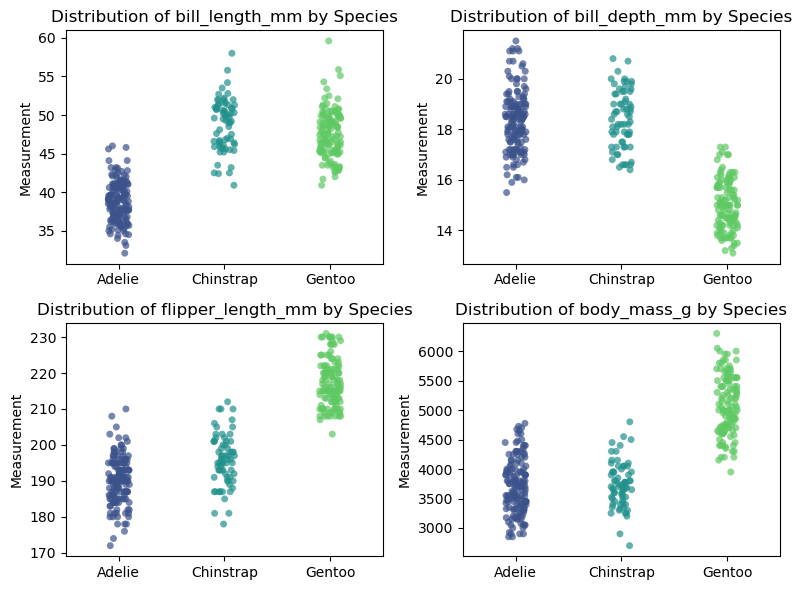

In [42]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes = axes.flatten()

for i, col in enumerate(features):
    sns.stripplot(data=penguins_cleaned, x='species', y=col, ax=axes[i], jitter=True, alpha=0.7, palette='viridis', hue='species', legend=False)
    
    axes[i].set_title(f'Distribution of {col} by Species')
    axes[i].set_ylabel('Measurement') 
    axes[i].set_xlabel('')
        
plt.tight_layout()
plt.show()

- The "Short-Billed" Chinstrap: In distribtuion of bill length by species plot, most dots are between 45 and 55. Closely at the bottom of that teal group—there is one dot sitting way down near 40. That penguin has a much shorter bill than almost every other Chinstrap

- The "Small" Gentoo:In flipper_length_mm plot, most Gentoos are high up (210 to 230), however there is one green dot sitting down at 200

In [43]:
from sklearn.preprocessing import StandardScaler

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_cleaned[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [44]:
# Convert back to dataframe 
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("First 5 rows of scaled data:")
X_scaled_df.head()

First 5 rows of scaled data:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


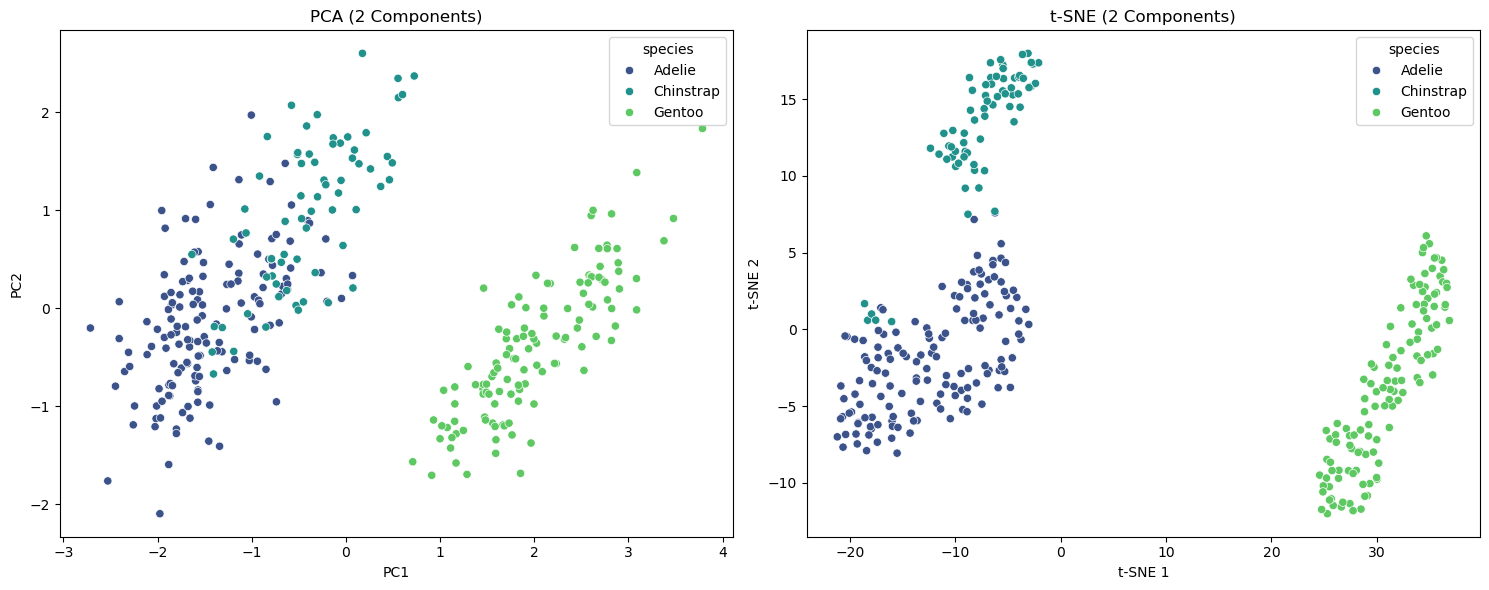

In [45]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['species'], palette='viridis', ax=axes[0])
axes[0].set_title('PCA (2 Components)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# t-SNE Plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=penguins_cleaned['species'], palette='viridis', ax=axes[1])
axes[1].set_title('t-SNE (2 Components)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

In [46]:
from sklearn.cluster import KMeans

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
penguins_cleaned['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(penguins_cleaned['kmeans_cluster'].value_counts())

kmeans_cluster
0    129
1    119
2     85
Name: count, dtype: int64


C:\Users\Hp Envy\anaconda3_new2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Hp Envy\AppData\Local\Temp\ipykernel_24672\224390568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned['kmeans_cluster'] = kmeans.fit_predict(X_scaled)


In [47]:
from sklearn.cluster import DBSCAN

dbscan1 = DBSCAN(eps=0.5, min_samples=5)
penguins_cleaned['dbscan_1'] = dbscan1.fit_predict(X_scaled)

dbscan2 = DBSCAN(eps=0.8, min_samples=5)
penguins_cleaned['dbscan_2'] = dbscan2.fit_predict(X_scaled)

print("DBSCAN 1 clusters:", penguins_cleaned['dbscan_1'].unique())
print("DBSCAN 2 clusters:", penguins_cleaned['dbscan_2'].unique())

DBSCAN 1 clusters: [ 0 -1  1  2  3]
DBSCAN 2 clusters: [ 0 -1  1]


C:\Users\Hp Envy\AppData\Local\Temp\ipykernel_24672\1968296537.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned['dbscan_1'] = dbscan1.fit_predict(X_scaled)
C:\Users\Hp Envy\AppData\Local\Temp\ipykernel_24672\1968296537.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned['dbscan_2'] = dbscan2.fit_predict(X_scaled)


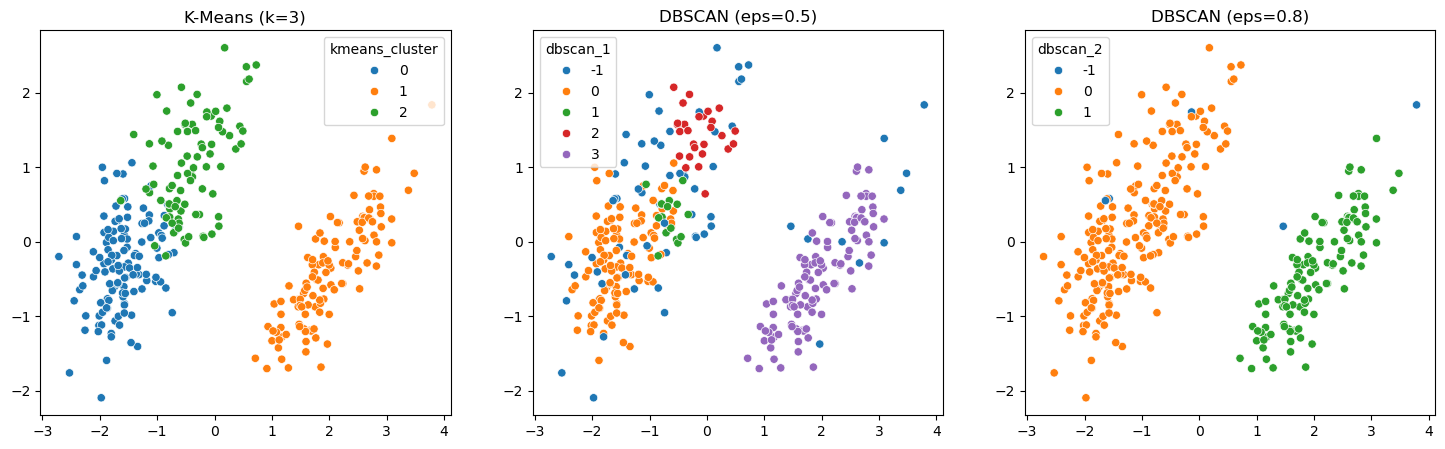

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['kmeans_cluster'], palette='tab10', ax=axes[0])
axes[0].set_title('K-Means (k=3)')

# Plot DBSCAN 1
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['dbscan_1'], palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN (eps=0.5)')

# Plot DBSCAN 2
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['dbscan_2'], palette='tab10', ax=axes[2])
axes[2].set_title('DBSCAN (eps=0.8)')

plt.show()

In [50]:
from sklearn.metrics import silhouette_score

# K-Means Score
kmeans_score = silhouette_score(X_scaled, penguins_cleaned['kmeans_cluster'])
print(f"K-Means Silhouette Score: {kmeans_score:.3f}")

# DBSCAN Experiment 1
labels1 = penguins_cleaned['dbscan_1']
if len(set(labels1) - {-1}) > 1:
    
    mask = labels1 != -1
    db1_score = silhouette_score(X_scaled[mask], labels1[mask])
    print(f"DBSCAN (eps=0.5) Silhouette Score: {db1_score:.3f}")
else:
    print("DBSCAN (eps=0.5): Not enough clusters to calculate score.")

# DBSCAN Experiment 2
labels2 = penguins_cleaned['dbscan_2']
if len(set(labels2) - {-1}) > 1:
    mask = labels2 != -1
    db2_score = silhouette_score(X_scaled[mask], labels2[mask])
    print(f"DBSCAN (eps=0.8) Silhouette Score: {db2_score:.3f}")
else:
    print("DBSCAN (eps=0.8): Not enough clusters to calculate score.")

K-Means Silhouette Score: 0.446
DBSCAN (eps=0.5) Silhouette Score: 0.422
DBSCAN (eps=0.8) Silhouette Score: 0.535


Adjusted Rand Index (ARI): 0.799
Normalized Mutual Information (NMI): 0.790


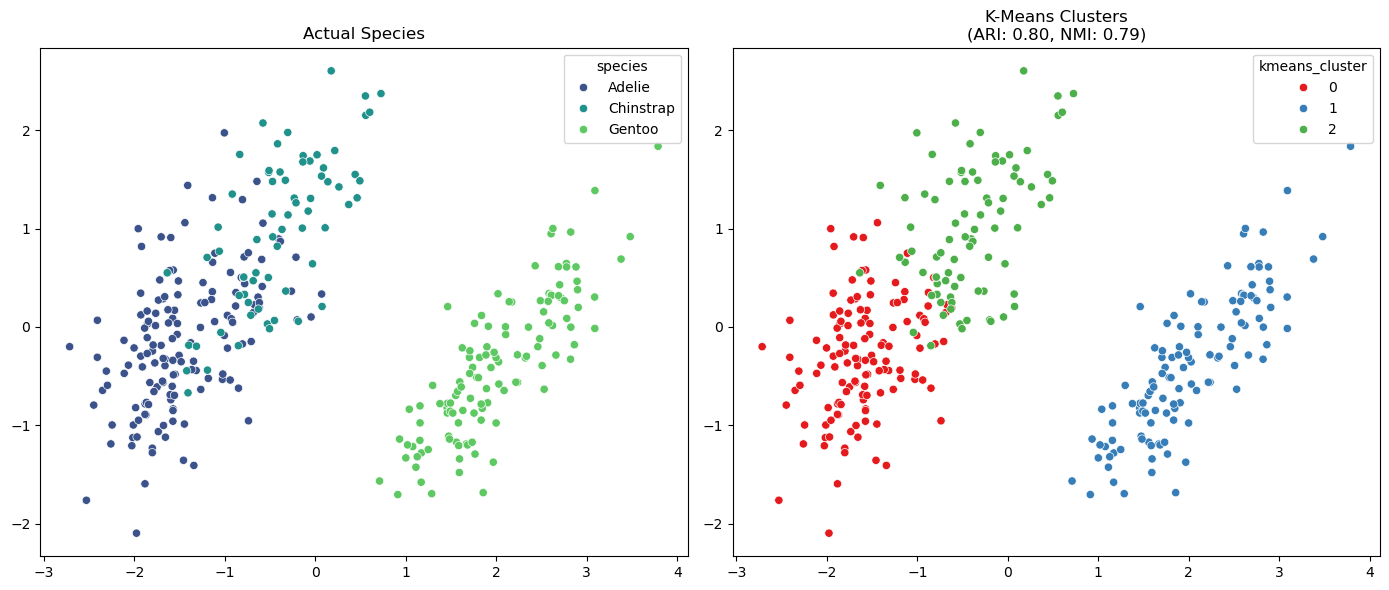

In [51]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate Scores
ari = adjusted_rand_score(penguins_cleaned['species'], penguins_cleaned['kmeans_cluster'])
nmi = normalized_mutual_info_score(penguins_cleaned['species'], penguins_cleaned['kmeans_cluster'])

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

# Visualize the Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual Species
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['species'], 
                palette='viridis', ax=axes[0])
axes[0].set_title('Actual Species')

# Plot 2: K-Means Clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=penguins_cleaned['kmeans_cluster'], 
                palette='Set1', ax=axes[1])
axes[1].set_title(f'K-Means Clusters\n(ARI: {ari:.2f}, NMI: {nmi:.2f})')

plt.tight_layout()
plt.show()

How well did they recover the structure?
Very well. With an ARI of 0.80, the algorithm successfully identified the three species roughly 80% better than random chance. It perfectly isolated Gentoos because their larger size makes them physically distinct from the other two groups.

Where did they fail?
The failure occurred at the Adélie-Chinstrap boundary. Because these two species have overlapping body mass and flipper lengths, the clustering algorithm struggled to find a clear "line" between them, leading to some misclassifications in the shared data space.

## Task 2 — Supervised Model Pipeline

In [52]:
from sklearn.model_selection import train_test_split

# Separate Features and Target
X = penguins_cleaned.drop(columns=['species'])
y = penguins_cleaned['species']

# Encode Categorical Variables (island and sex)
# We use One-Hot Encoding to turn categories into 0/1 columns
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

print("Features after encoding:")
print(X.columns.tolist())

Features after encoding:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'kmeans_cluster', 'dbscan_1', 'dbscan_2', 'island_Dream', 'island_Torgersen', 'sex_Male']


In [53]:
# Split the data
# stratify=y ensures each species is represented equally in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 266
Testing set size: 67


In [54]:
# Remove any rows with NaN values
penguins_final = penguins_cleaned.dropna().copy()

# Separate features and target
X = penguins_final.drop(columns=['species'])
y = penguins_final['species']

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify feature types
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [56]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit and transform the training data
X_train_transformed = preprocessor.fit_transform(X_train)

# Transform the test data using the same rules
X_test_transformed = preprocessor.transform(X_test)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate

# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Define the scoring metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

In [59]:
results_list = []

for name, model in models.items():
    # Perform 5-Fold Cross Validation
    cv_results = cross_validate(model, X_train_transformed, y_train, cv=5, scoring=scoring)
    
    # Store the average of each metric
    results_list.append({
        "Model": name,
        "Accuracy": cv_results['test_accuracy'].mean(),
        "Precision (Macro)": cv_results['test_precision_macro'].mean(),
        "Recall (Macro)": cv_results['test_recall_macro'].mean(),
        "F1 Score (Macro)": cv_results['test_f1_macro'].mean()
    })

# Convert to DataFrame for easy comparison
df_results = pd.DataFrame(results_list)
print(df_results)

                 Model  Accuracy  Precision (Macro)  Recall (Macro)  \
0  Logistic Regression  0.992453           0.994556        0.987273   
1        Random Forest  0.996226           0.997333        0.993333   
2                  SVM  0.996226           0.997333        0.993333   

   F1 Score (Macro)  
0          0.990538  
1          0.995131  
2          0.995131  


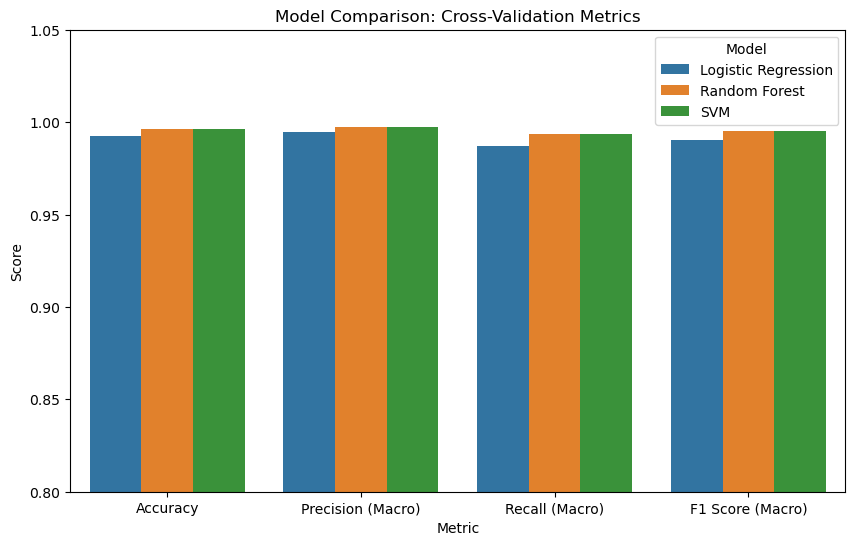

In [60]:
plt.figure(figsize=(10, 6))
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model')
plt.ylim(0.8, 1.05)
plt.title('Model Comparison: Cross-Validation Metrics')
plt.show()

In [61]:
# Sort by F1 Score to find the winner
best_model_row = df_results.sort_values(by="F1 Score (Macro)", ascending=False).iloc[0]
best_model_name = best_model_row["Model"]

print(f"The Best Model is: {best_model_name}")
print(f"Final F1 Score: {best_model_row['F1 Score (Macro)']:.4f}")

The Best Model is: Random Forest
Final F1 Score: 0.9951


In [62]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees in the forest
    'max_depth': [None, 10, 20],         # How deep each tree can grow
    'min_samples_split': [2, 5, 10],     # Minimum samples required to split a node
    'criterion': ['gini', 'entropy']     # Function to measure the quality of a split
}

# Initialize the grid search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                                # 5-fold cross-validation
    scoring='f1_macro',                  # Optimize for F1 Macro
    n_jobs=-1                            # Use all available processors
)

In [63]:
# Fit the grid search to the transformed training data
grid_search.fit(X_train_transformed, y_train)

# Output the winners
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9951


In [64]:
# Extract the best stats
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
default_score = df_results[df_results['Model'] == 'Random Forest']['F1 Score (Macro)'].values[0]

print("--- Optimization Report ---")
print(f"Best Hyperparameters: {best_params}")
print(f"Best CV F1 Score: {best_cv_score:.4f}")
print(f"Default CV F1 Score: {default_score:.4f}")
print(f"Improvement: {((best_cv_score - default_score) / default_score) * 100:.2f}%")

--- Optimization Report ---
Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9951
Default CV F1 Score: 0.9951
Improvement: 0.00%


In [65]:
from sklearn.metrics import classification_report

# Predictions from the tuned model
y_pred_tuned = grid_search.best_estimator_.predict(X_test_transformed)

print("\n[Final Tuned Model Classification Report]")
print(classification_report(y_test, y_pred_tuned))


[Final Tuned Model Classification Report]
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

